# Notebook 09 — Optimisation multi-objectifs physique + ML du procédé SWRO

**PFE — Master Science des Données**

## Objectif

Le Notebook 08 a montré qu'une optimisation purement pilotée par le MLP pouvait obtenir une forte réduction théorique de SEC, mais avec une divergence locale entre :

- la SEC prédite par le MLP ;
- la SEC observée dans les configurations physiques voisines.

Le Notebook 09 corrige ce point.

On recherche maintenant une configuration qui minimise simultanément :

1. la consommation énergétique prédite par le MLP ;
2. l'écart entre la prédiction ML et le comportement physique local ;
3. la distance au domaine d'apprentissage ;
4. le risque sous perturbations.

Le résultat final est donc un **optimum physique-contraint**, et non simplement le minimum du surrogate ML.


## 1. Principe méthodologique

Le Notebook 08 a montré qu'une optimisation purement pilotée par le MLP pouvait obtenir une forte réduction théorique de SEC, mais avec une divergence locale entre :

- la SEC prédite par le MLP ;
- la SEC observée dans les configurations physiques voisines.

Le Notebook 09 introduit donc une contrainte de **cohérence empirique locale**.

Pour une configuration `x`, on évalue :

1. la SEC prédite par le MLP ;
2. la SEC observée dans les configurations les plus proches du dataset physique V3 ;
3. la distance de Mahalanobis au domaine observé ;
4. la robustesse sous perturbations Monte Carlo.

Le résultat final est présenté comme un **candidat d'optimisation physique-contraint**, et non comme une validation industrielle.

> **Terminologie importante :** le terme "physique" désigne ici le dataset `dataset_physical_v3.csv`. La SEC locale n'est pas recalculée par un solveur physique pour un nouveau point.


In [1]:
# 2. Imports et configuration

from pathlib import Path
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

ROOT = Path(".")
DATA_DIR = ROOT / "data"
PREP_DIR = DATA_DIR / "preprocessed"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"

RESULT_DIR.mkdir(parents=True, exist_ok=True)

PHYSICAL_DATA_PATH = DATA_DIR / "dataset_physical_v3.csv"
MODEL_PATH = MODEL_DIR / "best_model_optimized.pkl"
SCALER_PARAMS_PATH = PREP_DIR / "scaler_parameters.csv"

FEATURES = [
    "pressure_bar",
    "feed_flow_m3_h",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
]

TARGET = "SEC_kWh_m3"
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print("Configuration chargée.")


Configuration chargée.


In [2]:
# 3. Chargement des données et du modèle

if not PHYSICAL_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset introuvable : {PHYSICAL_DATA_PATH}")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Modèle introuvable : {MODEL_PATH}")

if not SCALER_PARAMS_PATH.exists():
    raise FileNotFoundError(f"Scaler introuvable : {SCALER_PARAMS_PATH}")

df = pd.read_csv(PHYSICAL_DATA_PATH)
df_model = df[FEATURES + [TARGET]].dropna().copy()

model = joblib.load(MODEL_PATH)
scaler_params = pd.read_csv(SCALER_PARAMS_PATH).set_index("feature")

missing_features = [f for f in FEATURES if f not in df_model.columns]
if missing_features:
    raise ValueError(f"Features absentes : {missing_features}")

missing_scaler = [f for f in FEATURES if f not in scaler_params.index]
if missing_scaler:
    raise ValueError(f"Features absentes du scaler : {missing_scaler}")

mean_train = scaler_params.loc[FEATURES, "mean_train"].astype(float).values
std_train = scaler_params.loc[FEATURES, "std_train"].astype(float).values

def transform_physical(X):
    X = pd.DataFrame(X, columns=FEATURES)
    return (X.values - mean_train) / std_train

def predict_sec(X):
    return np.asarray(
        model.predict(transform_physical(X)),
        dtype=float
    )

X_obs = df_model[FEATURES].astype(float).values
y_obs = df_model[TARGET].astype(float).values

print("Dataset :", df_model.shape)
print("Modèle :", type(model).__name__)


Dataset : (10000, 9)
Modèle : MLPRegressor


,metric,value
0,MAE,0.087013
1,RMSE,0.110017
2,R2,0.953654


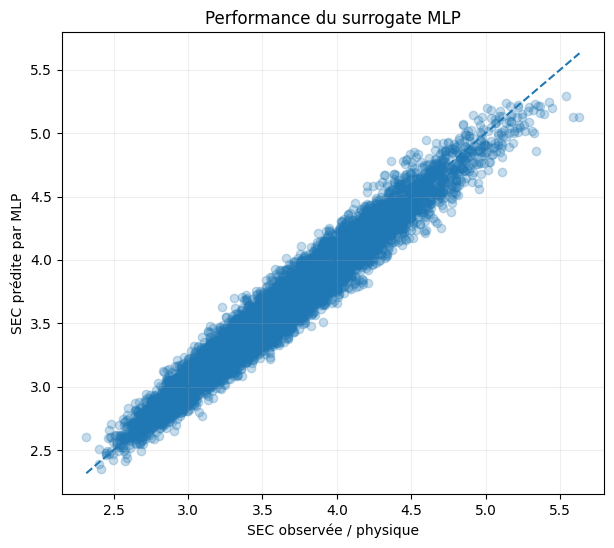

In [3]:
# 4. Vérification du surrogate

y_pred = predict_sec(df_model[FEATURES])

metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [
        mean_absolute_error(y_obs, y_pred),
        mean_squared_error(y_obs, y_pred) ** 0.5,
        r2_score(y_obs, y_pred),
    ],
})

display(metrics.round(6))

plt.figure(figsize=(7, 6))
plt.scatter(y_obs, y_pred, alpha=0.25)
lims = [min(y_obs.min(), y_pred.min()), max(y_obs.max(), y_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("SEC observée / physique")
plt.ylabel("SEC prédite par MLP")
plt.title("Performance du surrogate MLP")
plt.grid(alpha=0.2)
plt.show()


## 5. Domaine d'optimisation

Les bornes sont calculées à partir du domaine observé.

On utilise les quantiles 0.5 % et 99.5 % afin de réduire l'influence de valeurs extrêmes.


In [4]:
# 5. Bornes observées

bounds = pd.DataFrame({
    "min": df_model[FEATURES].min(),
    "q005": df_model[FEATURES].quantile(0.005),
    "median": df_model[FEATURES].median(),
    "q995": df_model[FEATURES].quantile(0.995),
    "max": df_model[FEATURES].max(),
})

display(bounds.round(5))

LOW = bounds["q005"].to_dict()
HIGH = bounds["q995"].to_dict()
MEDIAN = bounds["median"].to_dict()

LOW_ARRAY = np.array([LOW[f] for f in FEATURES])
HIGH_ARRAY = np.array([HIGH[f] for f in FEATURES])
X_MEDIAN = np.array([MEDIAN[f] for f in FEATURES])


,min,q005,median,q995,max
pressure_bar,55.00017,55.09069,62.38793,69.91848,69.99577
feed_flow_m3_h,200.12620,204.52161,604.71742,996.85388,999.93986
salinity_g_L,34.00038,34.04734,38.01654,41.95690,41.99921
temperature_C,15.00008,15.07497,22.50045,29.90691,29.99684
recovery_rate_target,0.30000,0.30067,0.37406,0.44935,0.45000
pump_efficiency,0.75000,0.75068,0.82591,0.89916,0.89999
erd_efficiency,0.80004,0.80078,0.88067,0.95916,0.95995
membrane_condition,0.75003,0.75096,0.87481,0.99856,0.99997


## 6. Domaine multivarié — Mahalanobis

On utilise la covariance des observations physiques pour caractériser le domaine multivarié.

Le seuil par défaut est le 95e percentile des distances observées.

Cette contrainte est volontairement plus stricte que celle du Notebook 08.


In [5]:
# 6. Distance de Mahalanobis

mu = X_obs.mean(axis=0)
cov = np.cov(X_obs, rowvar=False)
cov += np.eye(cov.shape[0]) * 1e-8
cov_inv = np.linalg.pinv(cov)

def mahalanobis_distance(x):
    x = np.asarray(x, dtype=float)
    d = x - mu
    return float(np.sqrt(d @ cov_inv @ d))

D_obs = np.array([mahalanobis_distance(x) for x in X_obs])

MAHAL_THRESHOLD = float(np.quantile(D_obs, 0.95))

print("Médiane observée :", round(float(np.median(D_obs)), 4))
print("Seuil 95 %       :", round(MAHAL_THRESHOLD, 4))
print("Maximum observé  :", round(float(D_obs.max()), 4))


Médiane observée : 2.8091
Seuil 95 %       : 3.5088
Maximum observé  : 4.3061


## 7. Modèle local du comportement physique

Le dataset physique ne permet pas d'évaluer exactement un nouveau point.

Nous construisons donc un estimateur local :

- recherche des `K` observations physiques les plus proches ;
- estimation de la SEC physique locale par médiane pondérée ;
- calcul de la dispersion locale.

La médiane est utilisée pour réduire l'influence des observations atypiques.


In [6]:
# 7. Estimateur empirique local du comportement physique

# Pour les voisins, les variables doivent être comparables.
# On utilise la standardisation du jeu d'observations (et non le scaler du MLP)
# afin que le débit, la pression, la salinité, etc. aient un poids comparable.

K_NEIGHBORS = 80

feature_mean = X_obs.mean(axis=0)
feature_std = X_obs.std(axis=0, ddof=1)
feature_std = np.where(feature_std == 0, 1.0, feature_std)

X_obs_scaled = (X_obs - feature_mean) / feature_std

nn = NearestNeighbors(
    n_neighbors=K_NEIGHBORS,
    metric="euclidean"
)
nn.fit(X_obs_scaled)

def local_physical_estimate(x):
    x = np.asarray(x, dtype=float)
    x_scaled = (x - feature_mean) / feature_std

    distances, indices = nn.kneighbors(x_scaled.reshape(1, -1))
    distances = distances[0]
    indices = indices[0]

    local_y = y_obs[indices]

    # Poids décroissants avec la distance.
    weights = 1.0 / (distances + 1e-6)
    weighted_mean = np.sum(weights * local_y) / np.sum(weights)

    return {
        "local_median": float(np.median(local_y)),
        "local_mean": float(np.mean(local_y)),
        "local_weighted_mean": float(weighted_mean),
        "local_std": float(np.std(local_y)),
        "nearest_sec": float(local_y[0]),
        "nearest_distance_scaled": float(distances[0]),
    }

print(f"Voisins utilisés pour l'estimation locale : K = {K_NEIGHBORS}")


Voisins utilisés pour l'estimation locale : K = 80


## 8. Risque Monte Carlo rapide

Pour rendre l'optimisation calculable, le risque est estimé avec un petit nombre de simulations pendant l'optimisation.

La validation finale utilisera 10 000 scénarios.


In [7]:
# 8. Perturbations et risque Monte Carlo

PERTURBATION = {
    "pressure_bar": ("abs", 2.0),
    "feed_flow_m3_h": ("rel", 0.05),
    "salinity_g_L": ("abs", 1.0),
    "temperature_C": ("abs", 2.0),
    "recovery_rate_target": ("abs", 0.02),
    "pump_efficiency": ("abs", 0.02),
    "erd_efficiency": ("abs", 0.02),
    "membrane_condition": ("abs", 0.03),
}

def generate_perturbations(x_center, n=250, seed=RANDOM_STATE):
    # Générateur local : l'objectif devient déterministe pendant l'optimisation.
    local_rng = np.random.default_rng(seed)

    x_center = np.asarray(x_center, dtype=float)
    samples = np.tile(x_center, (n, 1))

    for j, feature in enumerate(FEATURES):
        kind, amount = PERTURBATION[feature]

        if kind == "abs":
            noise = local_rng.normal(0, amount / 2, size=n)
        else:
            noise = local_rng.normal(0, amount / 2, size=n) * x_center[j]

        samples[:, j] += noise
        samples[:, j] = np.clip(
            samples[:, j],
            LOW_ARRAY[j],
            HIGH_ARRAY[j]
        )

    return pd.DataFrame(samples, columns=FEATURES)

def monte_carlo_risk(x, n=250, seed=RANDOM_STATE):
    X_mc = generate_perturbations(x, n=n, seed=seed)
    y_mc = predict_sec(X_mc)

    D_mc = np.array([
        mahalanobis_distance(row)
        for row in X_mc.values
    ])

    return {
        "mean": float(np.mean(y_mc)),
        "p95": float(np.quantile(y_mc, 0.95)),
        "std": float(np.std(y_mc)),
        "mahal_p95": float(np.quantile(D_mc, 0.95)),
        "mahal_exceedance": float(np.mean(D_mc > MAHAL_THRESHOLD)),
    }


## 9. Fonction objectif physique + ML

Les pondérations sont normalisées par des échelles représentatives.

### Pondérations initiales

- `w_sec = 0.45`
- `w_consistency = 0.30`
- `w_domain = 0.10`
- `w_risk = 0.15`

L'objectif est de ne pas sacrifier complètement l'économie d'énergie, tout en pénalisant fortement une solution ML qui serait incohérente avec son voisinage physique.


In [8]:
# 9. Fonction objectif physique + ML

# Pondérations initiales : elles totalisent 1.
W_SEC = 0.45
W_CONSISTENCY = 0.30
W_DOMAIN = 0.10
W_RISK = 0.15

if not np.isclose(
    W_SEC + W_CONSISTENCY + W_DOMAIN + W_RISK,
    1.0
):
    raise ValueError("Les pondérations doivent totaliser 1.")

# Echelles dérivées des données plutôt que choisies arbitrairement.
SEC_SCALE = float(np.median(y_obs))
CONSISTENCY_SCALE = float(np.std(y_obs, ddof=1))
RISK_SCALE = float(np.std(y_obs, ddof=1))

# Le seuil est une contrainte : une solution très atypique est fortement rejetée.
HARD_DOMAIN_MARGIN = 0.0

def objective_physical_ml(x):
    x = np.asarray(x, dtype=float)
    x_df = pd.DataFrame([x], columns=FEATURES)

    sec_ml = float(predict_sec(x_df)[0])
    local = local_physical_estimate(x)
    sec_phys = local["local_weighted_mean"]

    consistency_error = abs(sec_ml - sec_phys)
    d = mahalanobis_distance(x)

    # Contrainte dure sur le domaine multivarié.
    if d > MAHAL_THRESHOLD + HARD_DOMAIN_MARGIN:
        return 1e6 + 1e4 * (d - MAHAL_THRESHOLD)

    risk = monte_carlo_risk(x, n=150, seed=RANDOM_STATE)
    risk_penalty = max(0.0, risk["p95"] - sec_ml)

    objective = (
        W_SEC * (sec_ml / SEC_SCALE)
        + W_CONSISTENCY * (consistency_error / CONSISTENCY_SCALE)
        + W_DOMAIN * (d / MAHAL_THRESHOLD)
        + W_RISK * (risk_penalty / RISK_SCALE)
    )

    return float(objective)

print("Echelle SEC :", round(SEC_SCALE, 5))
print("Echelle cohérence :", round(CONSISTENCY_SCALE, 5))
print("Echelle risque :", round(RISK_SCALE, 5))


Echelle SEC : 3.57379
Echelle cohérence : 0.51107
Echelle risque : 0.51107


## 10. Optimisation multi-objectifs

Differential Evolution est utilisé car la fonction objectif contient des composantes non lisses provenant :

- des voisins ;
- de la médiane locale ;
- des pénalités ;
- du Monte Carlo.

Le résultat est un **candidat physique-contraint**.


In [9]:
# 10. Optimisation physique + ML

result = differential_evolution(
    objective_physical_ml,
    bounds=list(zip(LOW_ARRAY, HIGH_ARRAY)),
    seed=RANDOM_STATE,
    maxiter=150,
    popsize=15,
    tol=1e-7,
    polish=True,
    workers=1,
    updating="immediate",
)

x_candidate = np.asarray(result.x, dtype=float)

candidate_df = pd.DataFrame([x_candidate], columns=FEATURES)
candidate_sec_ml = float(predict_sec(candidate_df)[0])
candidate_local = local_physical_estimate(x_candidate)
candidate_risk = monte_carlo_risk(x_candidate, n=1000, seed=RANDOM_STATE + 1)
candidate_D = mahalanobis_distance(x_candidate)

print("Succès :", result.success)
print("Message :", result.message)
print("Objectif :", round(float(result.fun), 6))
print("SEC ML :", round(candidate_sec_ml, 6))
print("SEC empirique locale :", round(candidate_local["local_weighted_mean"], 6))
print("Erreur absolue ML/local :", round(
    abs(candidate_sec_ml - candidate_local["local_weighted_mean"]), 6
))
print("Distance Mahalanobis :", round(candidate_D, 6))
print("Seuil Mahalanobis :", round(MAHAL_THRESHOLD, 6))
print("Risque P95 SEC :", round(candidate_risk["p95"], 6))
print("P(Mahalanobis > seuil) :", round(candidate_risk["mahal_exceedance"], 4))

display(candidate_df.T.rename(columns={0: "value"}).round(6))


Succès : False
Message : Maximum number of iterations has been exceeded.
Objectif : 0.448812
SEC ML : 2.844423
SEC empirique locale : 2.845435
Erreur absolue ML/local : 0.001012
Distance Mahalanobis : 1.743721
Seuil Mahalanobis : 3.50884
Risque P95 SEC : 2.990903
P(Mahalanobis > seuil) : 0.0


,value
pressure_bar,58.931646
feed_flow_m3_h,664.180035
salinity_g_L,38.151641
temperature_C,23.227674
recovery_rate_target,0.410622
pump_efficiency,0.876118
erd_efficiency,0.900341
membrane_condition,0.856290


## 11. Evaluation finale à 10 000 simulations

Le candidat est maintenant évalué avec la même procédure de stress-test que le Notebook 08, mais avec 10 000 scénarios.


,value
SEC_base_ML,2.844423
SEC_mean_MC,2.847009
SEC_median_MC,2.845839
SEC_std_MC,0.085379
SEC_P05_MC,2.707425
SEC_P95_MC,2.988907
SEC_max_MC,3.204489
Mahalanobis_base,1.743721
Mahalanobis_P95,2.194757
Mahalanobis_exceedance,0.000000


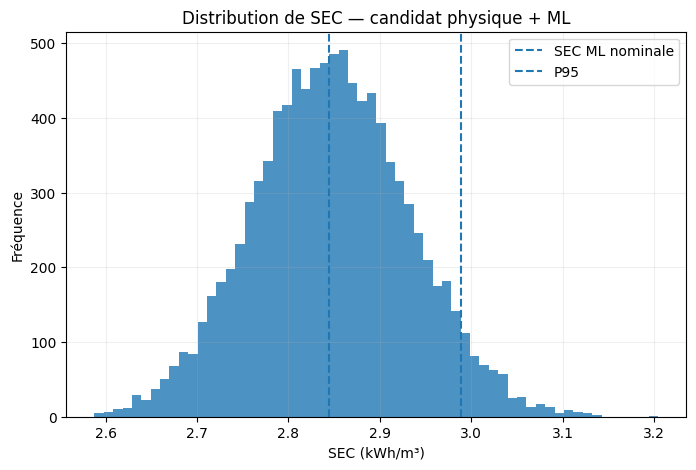

In [10]:
# 11. Evaluation finale à 10 000 simulations

N_FINAL = 10000

X_final = generate_perturbations(
    x_candidate,
    n=N_FINAL,
    seed=RANDOM_STATE + 2
)
y_final = predict_sec(X_final)

D_final = np.array([
    mahalanobis_distance(row)
    for row in X_final.values
])

final_stats = pd.Series({
    "SEC_base_ML": candidate_sec_ml,
    "SEC_mean_MC": np.mean(y_final),
    "SEC_median_MC": np.median(y_final),
    "SEC_std_MC": np.std(y_final),
    "SEC_P05_MC": np.quantile(y_final, 0.05),
    "SEC_P95_MC": np.quantile(y_final, 0.95),
    "SEC_max_MC": np.max(y_final),
    "Mahalanobis_base": candidate_D,
    "Mahalanobis_P95": np.quantile(D_final, 0.95),
    "Mahalanobis_exceedance": np.mean(D_final > MAHAL_THRESHOLD),
    "Local_SEC_empirical": candidate_local["local_weighted_mean"],
    "ML_Local_abs_error": abs(
        candidate_sec_ml - candidate_local["local_weighted_mean"]
    ),
})

display(final_stats.to_frame("value").round(6))

plt.figure(figsize=(8, 5))
plt.hist(y_final, bins=60, alpha=0.8)
plt.axvline(candidate_sec_ml, linestyle="--", label="SEC ML nominale")
plt.axvline(np.quantile(y_final, 0.95), linestyle="--", label="P95")
plt.xlabel("SEC (kWh/m³)")
plt.ylabel("Fréquence")
plt.title("Distribution de SEC — candidat physique + ML")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 12. Comparaison avec la référence

La référence est la configuration médiane du dataset.

On mesure :

- SEC nominale ;
- SEC moyenne Monte Carlo ;
- P95 ;
- gain énergétique ;
- cohérence ML/physique.


In [11]:
# 12. Référence médiane

ref_risk = monte_carlo_risk(
    X_MEDIAN,
    n=N_FINAL,
    seed=RANDOM_STATE + 3
)

ref_sec = float(predict_sec(
    pd.DataFrame([X_MEDIAN], columns=FEATURES)
)[0])

ref_local = local_physical_estimate(X_MEDIAN)

comparison = pd.DataFrame([
    {
        "configuration": "Référence médiane",
        "SEC_ML": ref_sec,
        "SEC_mean_MC": ref_risk["mean"],
        "SEC_P95": ref_risk["p95"],
        "Mahalanobis": mahalanobis_distance(X_MEDIAN),
        "SEC_empirical_local": ref_local["local_weighted_mean"],
        "ML_local_abs_error": abs(
            ref_sec - ref_local["local_weighted_mean"]
        ),
    },
    {
        "configuration": "Candidat physique + ML",
        "SEC_ML": candidate_sec_ml,
        "SEC_mean_MC": np.mean(y_final),
        "SEC_P95": np.quantile(y_final, 0.95),
        "Mahalanobis": candidate_D,
        "SEC_empirical_local": candidate_local["local_weighted_mean"],
        "ML_local_abs_error": abs(
            candidate_sec_ml - candidate_local["local_weighted_mean"]
        ),
    },
])

comparison["gain_SEC_mean_pct"] = (
    (comparison.loc[0, "SEC_mean_MC"] - comparison["SEC_mean_MC"])
    / comparison.loc[0, "SEC_mean_MC"] * 100
)

comparison["gain_SEC_P95_pct"] = (
    (comparison.loc[0, "SEC_P95"] - comparison["SEC_P95"])
    / comparison.loc[0, "SEC_P95"] * 100
)

display(comparison.round(5))


,configuration,SEC_ML,SEC_mean_MC,SEC_P95,Mahalanobis,SEC_empirical_local,ML_local_abs_error,gain_SEC_mean_pct,gain_SEC_P95_pct
0,Référence médiane,3.55580,3.55992,3.75426,0.02053,3.55113,0.00467,0.00000,0.00000
1,Candidat physique + ML,2.84442,2.84701,2.98891,1.74372,2.84543,0.00101,20.02601,20.38614


## 13. Analyse de sensibilité des pondérations

Une optimisation multi-objectifs dépend des poids.

On teste donc plusieurs scénarios :

- énergie prioritaire ;
- équilibre ;
- physique prioritaire.

Cela permet de vérifier si la configuration recommandée est stable.


In [12]:
# 13. Sensibilité des pondérations

WEIGHT_SCENARIOS = {
    "energie_prioritaire": (0.70, 0.15, 0.05, 0.10),
    "equilibre": (0.45, 0.30, 0.10, 0.15),
    "physique_prioritaire": (0.25, 0.55, 0.10, 0.10),
}

def make_objective(weights):
    w_sec, w_cons, w_domain, w_risk = weights

    if not np.isclose(sum(weights), 1.0):
        raise ValueError(f"Pondérations invalides : {weights}")

    def objective(x):
        x = np.asarray(x, dtype=float)
        sec_ml = float(predict_sec(
            pd.DataFrame([x], columns=FEATURES)
        )[0])

        local = local_physical_estimate(x)
        consistency = abs(sec_ml - local["local_weighted_mean"])
        d = mahalanobis_distance(x)

        if d > MAHAL_THRESHOLD:
            return 1e6 + 1e4 * (d - MAHAL_THRESHOLD)

        risk = monte_carlo_risk(x, n=120, seed=RANDOM_STATE + 10)
        risk_penalty = max(0.0, risk["p95"] - sec_ml)

        return float(
            w_sec * (sec_ml / SEC_SCALE)
            + w_cons * (consistency / CONSISTENCY_SCALE)
            + w_domain * (d / MAHAL_THRESHOLD)
            + w_risk * (risk_penalty / RISK_SCALE)
        )

    return objective

sensitivity_rows = []

for scenario, weights in WEIGHT_SCENARIOS.items():
    res = differential_evolution(
        make_objective(weights),
        bounds=list(zip(LOW_ARRAY, HIGH_ARRAY)),
        seed=RANDOM_STATE,
        maxiter=80,
        popsize=10,
        tol=1e-6,
        polish=True,
        workers=1,
    )

    x_s = np.asarray(res.x, dtype=float)
    sec_s = float(predict_sec(
        pd.DataFrame([x_s], columns=FEATURES)
    )[0])
    local_s = local_physical_estimate(x_s)
    risk_s = monte_carlo_risk(
        x_s,
        n=2000,
        seed=RANDOM_STATE + 20
    )

    sensitivity_rows.append({
        "scenario": scenario,
        "W_SEC": weights[0],
        "W_CONSISTENCY": weights[1],
        "W_DOMAIN": weights[2],
        "W_RISK": weights[3],
        "optimization_success": bool(res.success),
        "objective": float(res.fun),
        "SEC_ML": sec_s,
        "SEC_empirical_local": local_s["local_weighted_mean"],
        "ML_local_abs_error": abs(
            sec_s - local_s["local_weighted_mean"]
        ),
        "Mahalanobis": mahalanobis_distance(x_s),
        "SEC_P95": risk_s["p95"],
        "Mahalanobis_exceedance": risk_s["mahal_exceedance"],
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.round(5))


,scenario,W_SEC,W_CONSISTENCY,W_DOMAIN,W_RISK,optimization_success,objective,SEC_ML,SEC_empirical_local,ML_local_abs_error,Mahalanobis,SEC_P95,Mahalanobis_exceedance
0,energie_prioritaire,0.70,0.15,0.05,0.10,False,0.60217,2.69894,2.74817,0.04923,2.31133,2.83510,0.0
1,equilibre,0.45,0.30,0.10,0.15,False,0.45090,2.80679,2.80759,0.00080,1.99712,2.94654,0.0
2,physique_prioritaire,0.25,0.55,0.10,0.10,False,0.27535,2.91472,2.91472,0.00000,1.52197,3.06291,0.0


## 14. Visualisation de la cohérence ML / physique

Le graphique suivant montre directement la différence entre :

- SEC prédite par le MLP ;
- SEC physique locale estimée.

Cette différence devient un indicateur central de la fiabilité de l'optimisation.


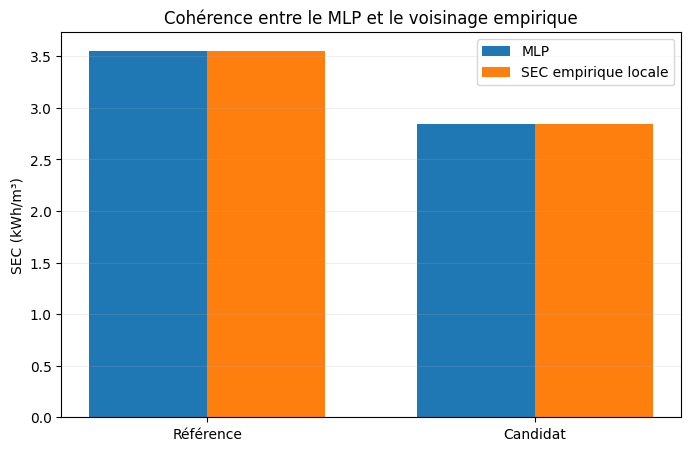

In [13]:
# 14. Cohérence MLP / comportement empirique local

labels = ["Référence", "Candidat"]

ml_values = [
    comparison.loc[0, "SEC_ML"],
    comparison.loc[1, "SEC_ML"],
]

empirical_values = [
    comparison.loc[0, "SEC_empirical_local"],
    comparison.loc[1, "SEC_empirical_local"],
]

x_pos = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(8, 5))
plt.bar(x_pos - width/2, ml_values, width, label="MLP")
plt.bar(x_pos + width/2, empirical_values, width, label="SEC empirique locale")
plt.xticks(x_pos, labels)
plt.ylabel("SEC (kWh/m³)")
plt.title("Cohérence entre le MLP et le voisinage empirique")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.show()


## 15. Résultat final et critères de décision

Une solution est considérée comme acceptable si :

1. elle reste dans les bornes observées ;
2. sa distance de Mahalanobis est sous le seuil ;
3. son erreur ML/physique est raisonnablement faible ;
4. son P95 reste maîtrisé ;
5. elle améliore la SEC par rapport à la référence.

Le notebook ne doit pas déclarer une solution "industriellement validée". Il doit parler de **configuration optimale selon le surrogate et les contraintes du dataset**.


In [14]:
# 15. Rapport final et critères de décision

# Ces seuils sont des critères méthodologiques du PFE.
# Ils doivent être présentés comme tels et non comme des normes industrielles.
ACCEPTANCE_ML_LOCAL_ERROR = 0.30
ACCEPTANCE_DOMAIN_EXCEEDANCE = 0.05

criteria = {
    "dans_domaine_Mahalanobis":
        bool(candidate_D <= MAHAL_THRESHOLD),
    "erreur_ML_locale":
        bool(final_stats["ML_Local_abs_error"] <= ACCEPTANCE_ML_LOCAL_ERROR),
    "risque_domaine":
        bool(final_stats["Mahalanobis_exceedance"] <= ACCEPTANCE_DOMAIN_EXCEEDANCE),
    "gain_SEC_moyenne_positif":
        bool(comparison.loc[1, "gain_SEC_mean_pct"] > 0),
}

decision = pd.DataFrame({
    "critere": list(criteria.keys()),
    "respecte": list(criteria.values()),
})

display(decision)

print("\nConfiguration candidate :")
display(
    pd.Series(x_candidate, index=FEATURES)
    .to_frame("value")
    .round(6)
)

print("\nDécision méthodologique :")
if all(criteria.values()):
    print("ACCEPTÉE comme candidat optimal physique-contraint du dataset.")
else:
    print("À REJETER / À AMÉLIORER : au moins un critère de robustesse ou de cohérence n'est pas satisfait.")

print("\nImportant :")
print("La SEC locale est une estimation empirique à partir des observations voisines.")
print("Elle ne constitue pas une nouvelle simulation physique du procédé.")


,critere,respecte
0,dans_domaine_Mahalanobis,True
1,erreur_ML_locale,True
2,risque_domaine,True
3,gain_SEC_moyenne_positif,True



Configuration candidate :


,value
pressure_bar,58.931646
feed_flow_m3_h,664.180035
salinity_g_L,38.151641
temperature_C,23.227674
recovery_rate_target,0.410622
pump_efficiency,0.876118
erd_efficiency,0.900341
membrane_condition,0.856290



Décision méthodologique :
ACCEPTÉE comme candidat optimal physique-contraint du dataset.

Important :
La SEC locale est une estimation empirique à partir des observations voisines.
Elle ne constitue pas une nouvelle simulation physique du procédé.


In [15]:
# 16. Sauvegarde des résultats

def python_scalar(value):
    if isinstance(value, (np.bool_, bool)):
        return bool(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value)
    if pd.isna(value):
        return None
    return value

def records_to_json(records):
    cleaned = []
    for row in records:
        cleaned.append({
            str(k): python_scalar(v)
            for k, v in row.items()
        })
    return cleaned

report = {
    "model_metrics": records_to_json(
        metrics.to_dict(orient="records")
    ),
    "comparison": records_to_json(
        comparison.to_dict(orient="records")
    ),
    "sensitivity": records_to_json(
        sensitivity_df.to_dict(orient="records")
    ),
    "candidate_features": {
        str(k): float(v)
        for k, v in zip(FEATURES, x_candidate.tolist())
    },
    "candidate_sec_ml": float(candidate_sec_ml),
    "candidate_local_empirical_sec": float(
        candidate_local["local_weighted_mean"]
    ),
    "candidate_mahalanobis": float(candidate_D),
    "mahalanobis_threshold": float(MAHAL_THRESHOLD),
    "final_stats": {
        str(k): python_scalar(v)
        for k, v in final_stats.to_dict().items()
    },
    "criteria": {
        str(k): bool(v)
        for k, v in criteria.items()
    },
}

with open(
    RESULT_DIR / "notebook09_physical_ml_optimization.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        report,
        f,
        ensure_ascii=False,
        indent=2
    )

comparison.to_csv(
    RESULT_DIR / "notebook09_comparison.csv",
    index=False
)

sensitivity_df.to_csv(
    RESULT_DIR / "notebook09_weight_sensitivity.csv",
    index=False
)

pd.DataFrame({
    "feature": FEATURES,
    "candidate_physical_ml": x_candidate,
    "reference_median": X_MEDIAN,
}).to_csv(
    RESULT_DIR / "notebook09_configurations.csv",
    index=False
)

print("Résultats sauvegardés dans :", RESULT_DIR)


Résultats sauvegardés dans : results


# Conclusion du Notebook 09

Le Notebook 09 améliore l'optimisation du Notebook 08 en empêchant le surrogate ML de rechercher uniquement des minima favorables à ses propres extrapolations.

La méthodologie finale combine :

- **MLP** : recherche de configurations énergétiquement intéressantes ;
- **voisinage empirique du dataset physique V3** : contrôle de cohérence locale ;
- **distance de Mahalanobis** : contrôle du domaine multivarié ;
- **Monte Carlo** : analyse de robustesse ;
- **sensibilité des pondérations** : vérification de la stabilité de la solution.

### Interprétation pour le mémoire

Le résultat ne doit pas être présenté comme :

> « la consommation physique réelle est réduite de X %. »

Il doit être présenté comme :

> « selon le surrogate MLP et sous les contraintes définies à partir du dataset physique V3, la configuration candidate présente une réduction estimée de X % de la SEC, avec une analyse de robustesse et un contrôle de cohérence locale. »

La prochaine étape est le **Notebook 10 — Synthèse scientifique**, destiné à produire les tableaux et figures finaux du PFE à partir des résultats réellement obtenus.
